# Mushroom Edibility Classifier

This notebook explores the mushroom dataset, visualizes key categorical patterns, prepares the features, and compares several classification models for edible vs. poisonous prediction.


In [83]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
sns.set_theme(style='whitegrid', font='DejaVu Sans')
PALETTE   = {'e': '#2ecc71', 'p': '#e74c3c'}
EDIBLE    = '#2ecc71'
POISONOUS = '#e74c3c'
BG        = '#f8f9fa'

mushroom_dataset=pd.read_csv("data/mushrooms.csv")
mushroom_dataset.head().T

,0,1,2,3,4
class,p,e,e,p,e
cap-shape,x,x,b,x,x
cap-surface,s,s,s,y,s
cap-color,n,y,w,w,g
bruises,t,t,t,t,f
odor,p,a,l,p,n
gill-attachment,f,f,f,f,f
gill-spacing,c,c,c,c,w
gill-size,n,b,b,n,b
gill-color,k,k,n,n,k


## 1. Data Overview

We start by loading the dataset and checking its structure, summary statistics, missing values, and class balance.


In [69]:
mushroom_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [70]:
mushroom_dataset.describe().T

,count,unique,top,freq
class,8124,2,e,4208
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises,8124,2,f,4748
odor,8124,9,n,3528
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,12,b,1728


In [71]:
print(mushroom_dataset.isna().sum().sum())
print(mushroom_dataset.duplicated().sum())

0
0


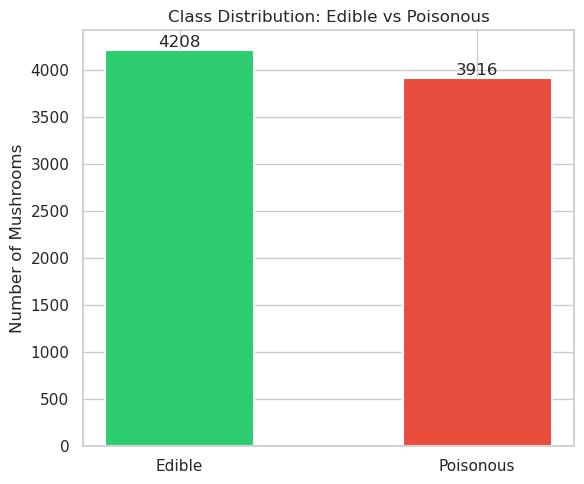

In [72]:
counts = mushroom_dataset['class'].value_counts()
labels = ['Edible', 'Poisonous']
colors = [EDIBLE, POISONOUS]

fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
ax.bar_label(bars, fmt='%d')

ax.set_title('Class Distribution: Edible vs Poisonous')
ax.set_ylabel('Number of Mushrooms')
ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.show()

## 2. Exploratory Feature Analysis

These plots highlight how selected mushroom attributes differ between edible and poisonous classes.


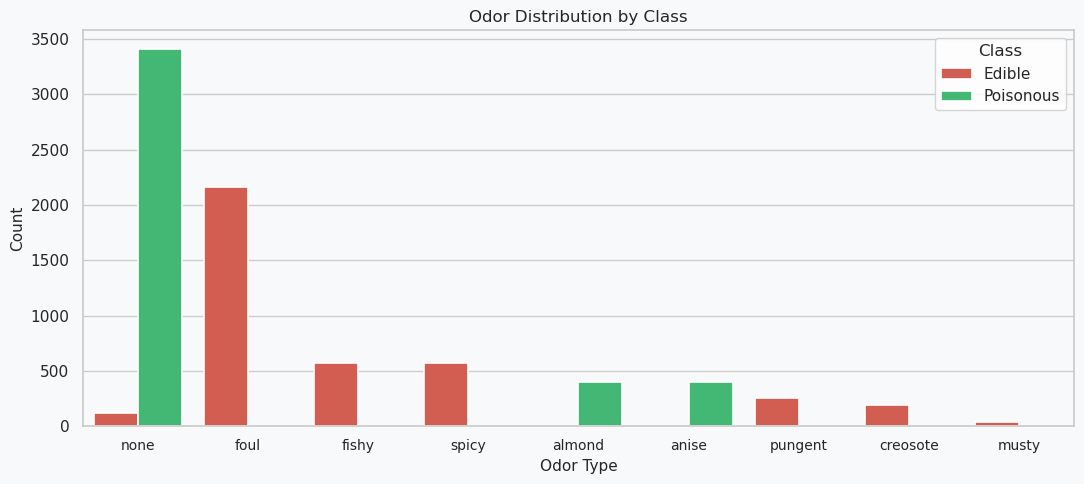

In [73]:
# ── Cell 3 · Odor by Class ────────────────────────────────────────
odor_map = {'a':'almond','l':'anise','c':'creosote','y':'fishy',
            'f':'foul','m':'musty','n':'none','p':'pungent','s':'spicy'}
mushroom_dataset['odor_label'] = mushroom_dataset['odor'].map(odor_map)

fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
ax.set_facecolor(BG)

sns.countplot(
    data=mushroom_dataset, x='odor_label', hue='class',
    palette=PALETTE, linewidth=1.2,
    order=mushroom_dataset['odor_label'].value_counts().index, ax=ax
)

ax.set_title('Odor Distribution by Class')
ax.set_xlabel('Odor Type', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.tick_params(axis='x', labelsize=10)
ax.legend(title='Class', labels=['Edible', 'Poisonous'])

plt.tight_layout()
plt.show()

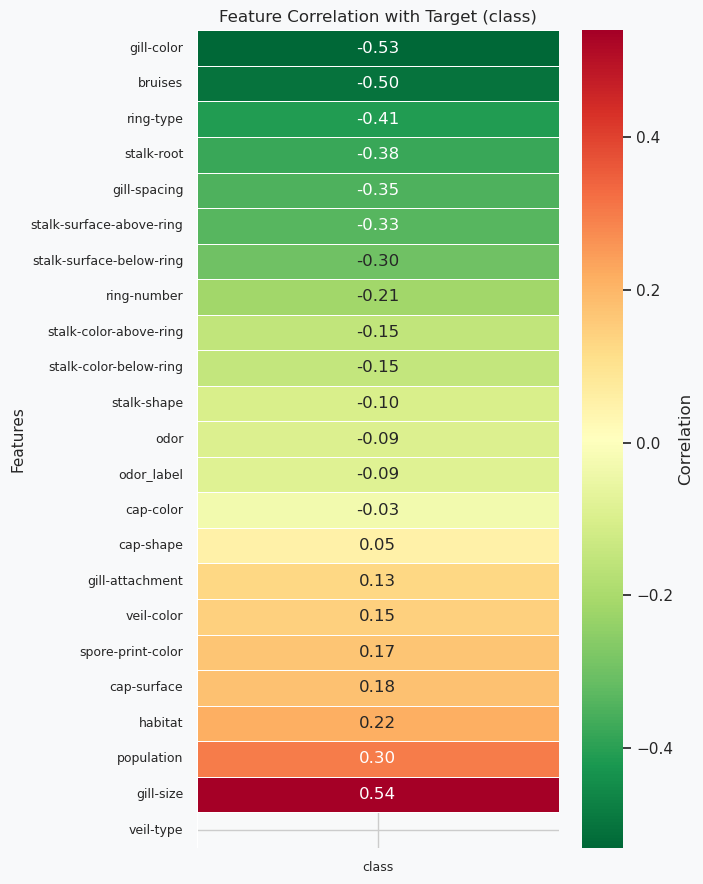

In [74]:
df_enc = mushroom_dataset.apply(LabelEncoder().fit_transform)
corr = df_enc.corr()[['class']].drop('class').sort_values('class')

fig, ax = plt.subplots(figsize=(7, 9), facecolor=BG)
ax.set_facecolor(BG)

sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlGn_r',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Correlation'},
    ax=ax
)

ax.set_title('Feature Correlation with Target (class)')
ax.set_xlabel('')
ax.set_ylabel('Features', fontsize=11)
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.show()

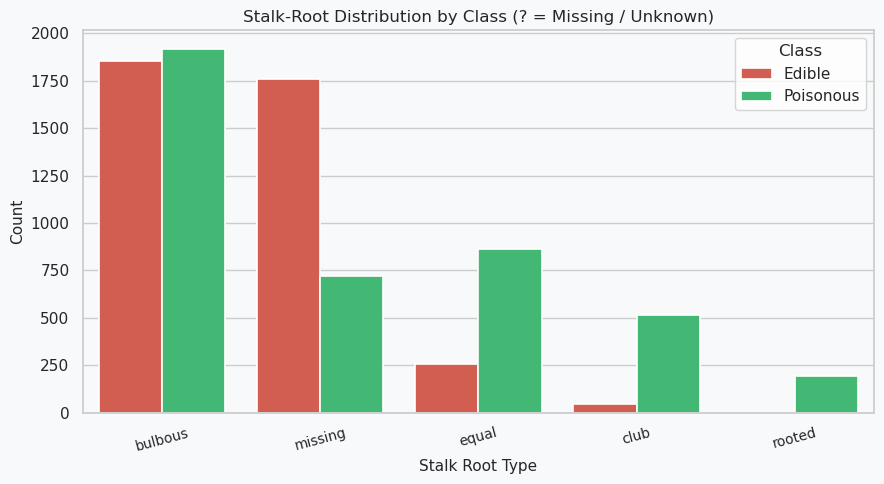

In [75]:
# ── Cell 5 · stalk-root ? by Class ───────────────────────────────
root_map = {'b':'bulbous','c':'club','u':'cup',
            'e':'equal','z':'rhizomorphs','r':'rooted','?':'missing'}
mushroom_dataset['root_label'] = mushroom_dataset['stalk-root'].map(root_map)

fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
ax.set_facecolor(BG)

sns.countplot(
    data=mushroom_dataset, x='root_label', hue='class',
    palette=PALETTE, edgecolor='white', linewidth=1.2,
    order=mushroom_dataset['root_label'].value_counts().index, ax=ax
)

ax.set_title('Stalk-Root Distribution by Class (? = Missing / Unknown)')
ax.set_xlabel('Stalk Root Type', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.tick_params(axis='x', rotation=15, labelsize=10)
ax.legend(title='Class', labels=['Edible', 'Poisonous'])

plt.tight_layout()
plt.show()

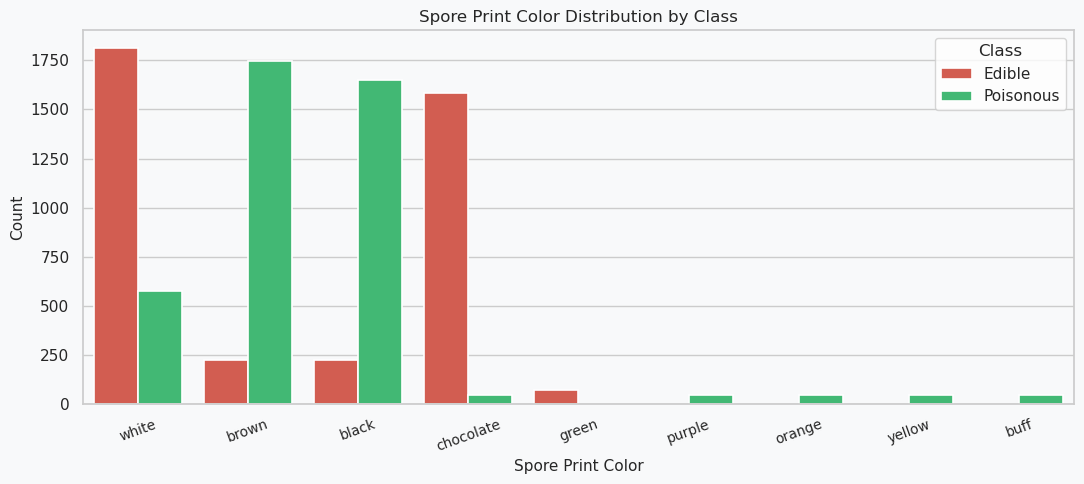

In [76]:
# ── Cell 6 · Spore Print Color by Class ──────────────────────────
spore_map = {'k':'black','n':'brown','b':'buff','h':'chocolate',
             'r':'green','o':'orange','u':'purple','w':'white','y':'yellow'}
mushroom_dataset['spore_label'] = mushroom_dataset['spore-print-color'].map(spore_map)

fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
ax.set_facecolor(BG)

sns.countplot(
    data=mushroom_dataset, x='spore_label', hue='class',
    palette=PALETTE, edgecolor='white', linewidth=1.2,
    order=mushroom_dataset['spore_label'].value_counts().index, ax=ax
)

ax.set_title('Spore Print Color Distribution by Class')
ax.set_xlabel('Spore Print Color', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.tick_params(axis='x', rotation=20, labelsize=10)
ax.legend(title='Class', labels=['Edible', 'Poisonous'])

plt.tight_layout()
plt.show()

## 3. Preprocessing

The target is encoded numerically, the constant `veil-type` column is removed, and the feature set is prepared for model training.


In [77]:
df = mushroom_dataset.drop(columns=['veil-type'])

le = LabelEncoder()
df_enc = df.apply(le.fit_transform)

print("Shape:", df_enc.shape)


Shape: (8124, 25)


In [78]:
# ── Cell 2 · Verify stalk-root kept '?' as a category ────────────
print("stalk-root unique values before encoding:", df['stalk-root'].unique())
print("stalk-root unique values after encoding :", df_enc['stalk-root'].unique())

stalk-root unique values before encoding: ['e' 'c' 'b' 'r' '?']
stalk-root unique values after encoding : [3 2 1 4 0]


In [79]:
X = df_enc.drop(columns=['class'])
y = df_enc['class']   # 0 = edible, 1 = poisonous

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

X shape: (8124, 24)
y distribution:
 class
0    4208
1    3916
Name: count, dtype: int64


## 4. Train-Test Split and Models

We split the dataset into training and test sets, then define a small model benchmark for comparison.


In [80]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=2,test_size=0.2,stratify=y)
X_test.shape

(1625, 24)

In [82]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : XGBClassifier(n_estimators=100, random_state=42)
}

## 5. Model Comparison

After training each model, we compare their accuracies to identify the strongest baseline.


In [84]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = accuracy_score(y_test, preds)
    print(f"{name:25s} → Accuracy: {results[name]:.4f}")

Logistic Regression       → Accuracy: 0.9612
Decision Tree             → Accuracy: 1.0000
Random Forest             → Accuracy: 1.0000
Gradient Boosting         → Accuracy: 1.0000


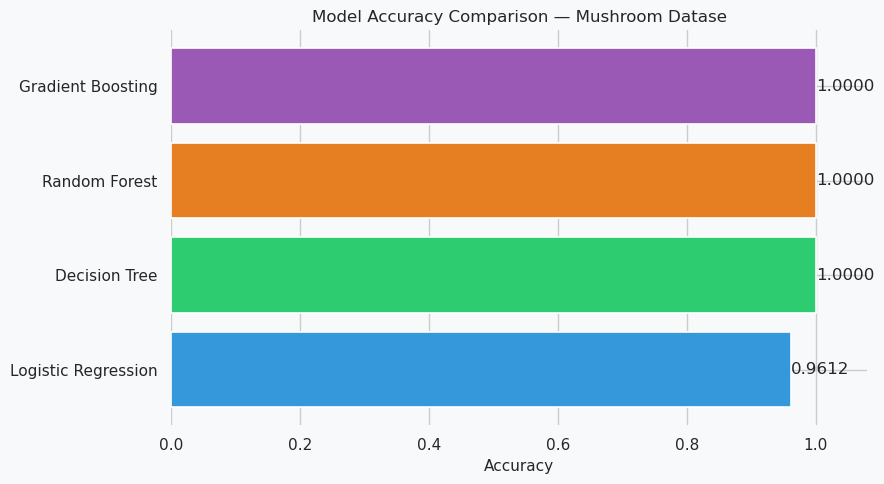

In [86]:
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
ax.set_facecolor(BG)

bars = ax.barh(
    list(results.keys()),
    list(results.values()),
    color=['#3498db', '#2ecc71', '#e67e22', '#9b59b6'],
    edgecolor='white', linewidth=1.2
)
ax.bar_label(bars, fmt='%.4f')
ax.set_xlim(0, 1.08)
ax.set_title('Model Accuracy Comparison — Mushroom Datase')
ax.set_xlabel('Accuracy', fontsize=11)
ax.tick_params(labelsize=11)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

## 6. Detailed Evaluation

We inspect classification reports and confusion matrices to understand where each model makes mistakes.


In [87]:
for name, model in models.items():
    preds = model.predict(X_test)
    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    print(classification_report(y_test, preds, target_names=['Edible', 'Poisonous']))


──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
              precision    recall  f1-score   support

      Edible       0.97      0.96      0.96       842
   Poisonous       0.95      0.97      0.96       783

    accuracy                           0.96      1625
   macro avg       0.96      0.96      0.96      1625
weighted avg       0.96      0.96      0.96      1625


──────────────────────────────────────────────────
  Decision Tree
──────────────────────────────────────────────────
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625


──────────────────────────────────────────────────
  Random Forest
──────────────────────────────────

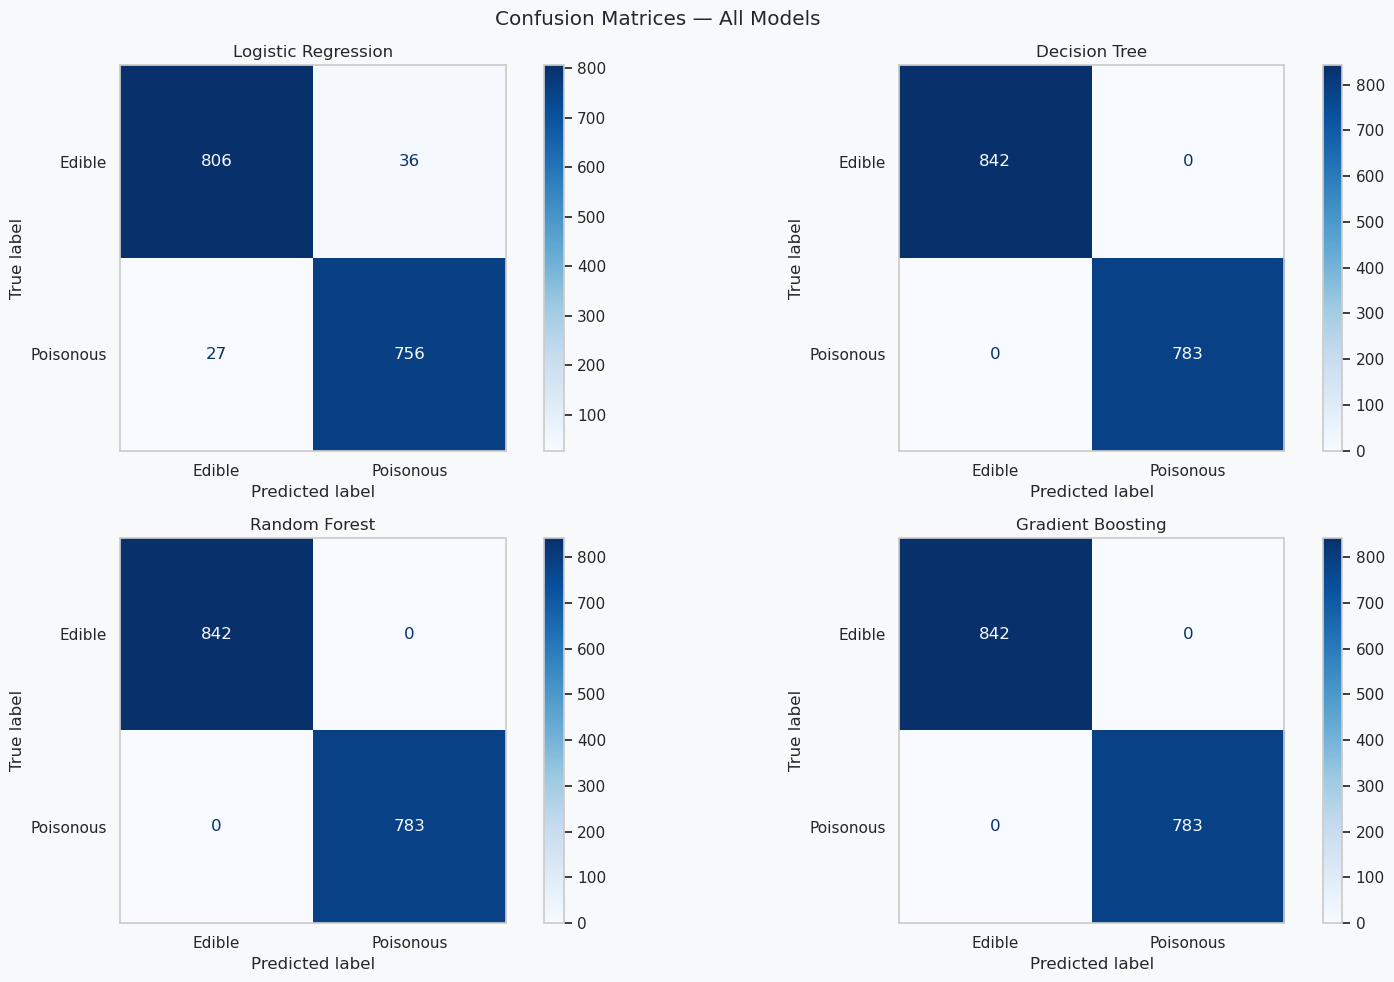

In [100]:
fig, axes = plt.subplots(2, 2, figsize=(16,10), facecolor=BG)
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    ax.set_facecolor(BG)
    preds = model.predict(X_test)
    cm    = confusion_matrix(y_test, preds)
    disp  = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Edible', 'Poisonous'])
    disp.plot(cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.grid(False)

fig.suptitle('Confusion Matrices — All Models')
plt.tight_layout()
plt.show()

## 7. Feature Importance

Random Forest feature importances help us see which mushroom attributes contribute most to the prediction.


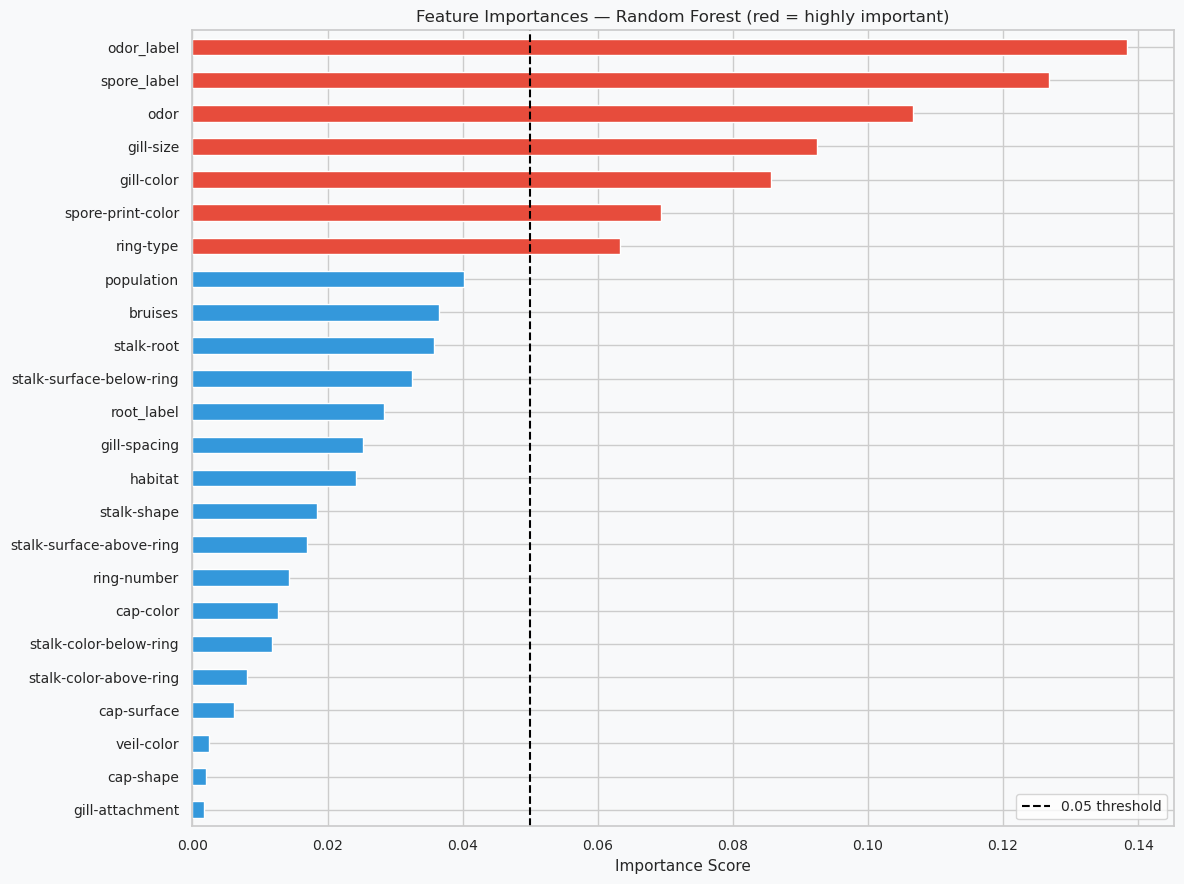

In [105]:
rf = models['Random Forest']
importances = (pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(12, 9), facecolor=BG)
ax.set_facecolor(BG)

colors = ['#e74c3c' if v > 0.05 else '#3498db' for v in importances]
importances.plot(kind='barh', color=colors, ax=ax)

ax.set_title('Feature Importances — Random Forest (red = highly important)')
ax.set_xlabel('Importance Score', fontsize=11)
ax.tick_params(labelsize=10)
ax.axvline(0.05, color='black',linestyle='--',label='0.05 threshold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()